In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv("datos/train.csv")
test = pd.read_csv("datos/test.csv")
gender_submission = pd.read_csv("datos/gender_submission.csv")

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train.shape

(891, 12)

In [5]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [6]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
supervivencia = train["Survived"].value_counts()

print(supervivencia)

Survived
0    549
1    342
Name: count, dtype: int64


In [9]:
print(train["Survived"].value_counts(normalize=True) * 100)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [10]:
supervivencia_sexo = train.groupby("Sex")["Survived"].mean() * 100

print(supervivencia_sexo)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


In [11]:
supervivencia_clase = train.groupby("Pclass")["Survived"].mean() * 100

print(supervivencia_clase)

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


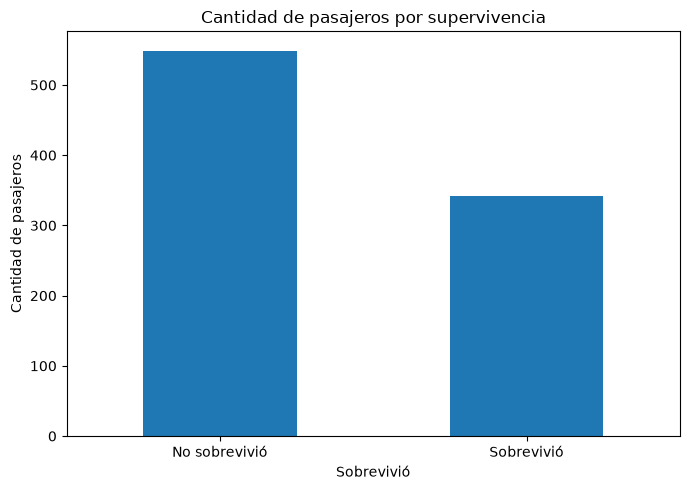

In [13]:
plt.figure(figsize=(7, 5))

train["Survived"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Cantidad de pasajeros por supervivencia")
plt.xlabel("Sobrevivió")
plt.ylabel("Cantidad de pasajeros")

plt.xticks(
    [0, 1],
    ["No sobrevivió", "Sobrevivió"],
    rotation=0
)

plt.tight_layout()
plt.show()

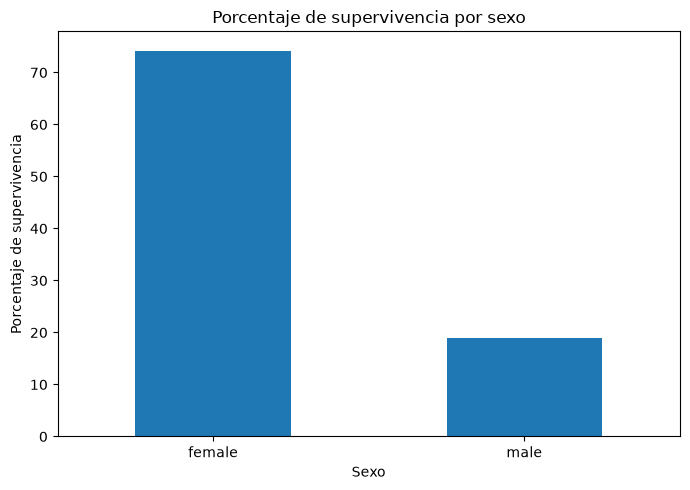

In [14]:
plt.figure(figsize=(7, 5))

supervivencia_sexo.plot(kind="bar")

plt.title("Porcentaje de supervivencia por sexo")
plt.xlabel("Sexo")
plt.ylabel("Porcentaje de supervivencia")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

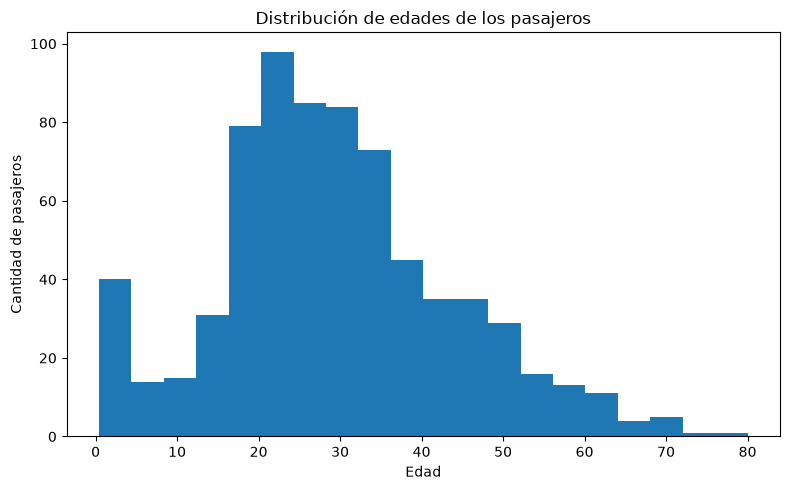

In [15]:
plt.figure(figsize=(8, 5))

train["Age"].plot(
    kind="hist",
    bins=20
)

plt.title("Distribución de edades de los pasajeros")
plt.xlabel("Edad")
plt.ylabel("Cantidad de pasajeros")

plt.tight_layout()
plt.show()